# Load in packages and data

In [9]:
## Import packages

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import shapefile

## Load in data

ds_cGAN = xr.open_dataset('../datasets/east_africa-cgan_forecast-20240422.nc')


# Load in shapefiles

In [11]:
## Gets lon and lat extents based on the shapefile

def get_region_extent(region, border_size=0.5):
    
    # The countries in the shapefile
    shapefile_countries = np.array(['Kenya','South Sudan','Rwanda','Burundi','Djibouti','Eritrea',
                                    'Ethiopia','Sudan','Somalia','Tanzania','Kenya2','Uganda',])

    # Get the shapefile
    sf = shapefile.Reader("../datasets/GHA_shapes/gha.shp")

    # Find the bounding box of the region
    if (region in shapefile_countries):
        i = int(np.nonzero(shapefile_countries == region)[0])
        bbox = np.array(sf.shape(i).bbox)
    else:
        bbox = np.array(sf.bbox)
        if (region != "ICPAC"):
            print(f"Warning: Region '{region}' is not known")

    # The boundary of the region in the form of a cartopy extent
    country_extent = [bbox[0] - border_size,
                      bbox[2] + border_size,
                      bbox[1] - border_size,
                      bbox[3] + border_size]
    
    return country_extent



In [12]:
# Load the border shapefile
reader = shpreader.Reader("../datasets/GHA_shapes/gha.shp")
borders_feature = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(), facecolor='none')

region = 'Kenya' ## can change this to Ethiopia

# Load the regions shapefile
reader = shpreader.Reader(f"../datasets/{region}_shapes/{region}_region.shp")
regions_feature = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(), facecolor='none')

# Get the extent of the region that we are looking at
region_extent = get_region_extent(region, border_size=0.5)


/var/folders/z9/7vk0kbx55g91_3mr8vw6gt_80000gp/T/ipykernel_70465/374816264.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i = int(np.nonzero(shapefile_countries == region)[0])


## Plot the data
#### We do it for the ensemble mean can you do it for median and std?
#### Hint see these links: https://docs.xarray.dev/en/stable/generated/xarray.DataArray.median.html
####                       https://docs.xarray.dev/en/latest/generated/xarray.DataArray.std.html

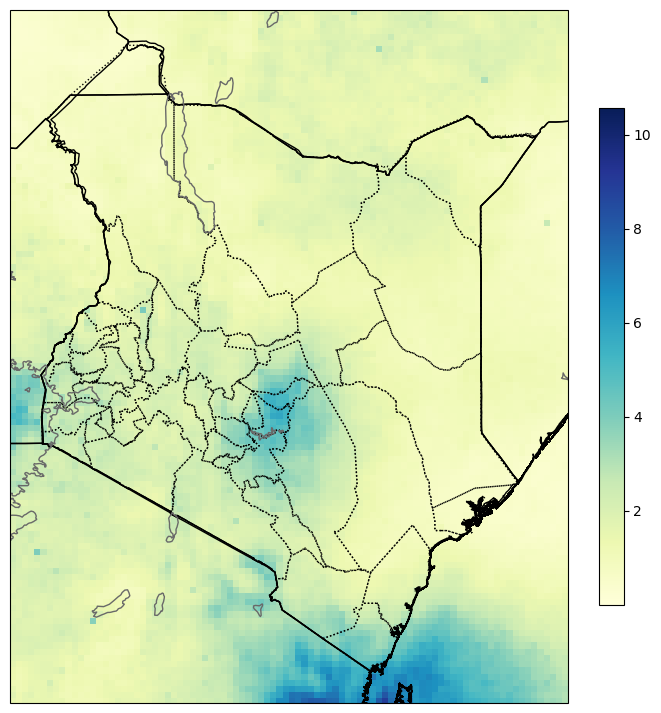

In [20]:
## intialise figure where you will plot
fig = plt.figure(figsize=(8,9))
ax = fig.add_subplot(1,1,1, projection = ccrs.PlateCarree())

## Add shapely features
ax.add_feature(cfeature.COASTLINE, linewidth=1)  # Draw some features to see where we are
ax.add_feature(regions_feature, linestyle=':')
ax.set_extent(region_extent, crs=ccrs.PlateCarree())
ax.add_feature(borders_feature)  # The borders
ax.add_feature(cfeature.LAKES, linewidth=1,linestyle='-',edgecolor='dimgrey',facecolor='none')

## Get data to plot
data_to_plot = ds_cGAN.precipitation.sum('valid_time').mean('member').values

## Create plot, note we use np.squeeze to remove any dimensions of size 1
c = ax.pcolormesh(ds_cGAN['longitude'], ds_cGAN['latitude'], np.squeeze(data_to_plot), cmap='YlGnBu', transform=ccrs.PlateCarree())
  
## Add a colorbar with a nice size
cb = plt.colorbar(c, fraction=0.04)
